In [ ]:

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/brain_tumor_segmentation_project"

import os
os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/brain_tumor_segmentation_project


In [ ]:

import os
import cv2
import glob
import time
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()

print("Device:", DEVICE)
print("AMP:", USE_AMP)

PROJECT_DIR = Path(PROJECT_DIR)
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
TABLE_DIR = PROJECT_DIR / "tables"
FIGURE_DIR = PROJECT_DIR / "figures"
PRED_DIR = PROJECT_DIR / "predictions"

for d in [CHECKPOINT_DIR, TABLE_DIR, FIGURE_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", PROJECT_DIR)


Device: cuda
AMP: True
Saving outputs to: /content/drive/MyDrive/brain_tumor_segmentation_project


In [4]:
%cd /content/drive/MyDrive/brain_tumor_segmentation_project

!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip

/content/drive/MyDrive/brain_tumor_segmentation_project
Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:40<00:00, 18.7MB/s]

replace lgg-mri-segmentation/kaggle_3m/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_10.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_10_mask.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_11.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
DATASET_PATH = "/content/drive/MyDrive/brain_tumor_segmentation_project/kaggle_3m"


In [ ]:
image_paths = []
mask_paths = []

for mask_path in sorted(glob.glob(os.path.join(DATASET_PATH, "**", "*_mask.tif"), recursive=True)):
    img_path = mask_path.replace("_mask.tif", ".tif")
    if os.path.exists(img_path):
        image_paths.append(img_path)
        mask_paths.append(mask_path)

print("Total image-mask pairs:", len(image_paths))

assert len(image_paths) > 0, "No image-mask pairs found. Please check DATASET_PATH."


Total image-mask pairs: 3929


In [ ]:

USE_POSITIVE_MASKS_ONLY = True

if USE_POSITIVE_MASKS_ONLY:
    pos_images, pos_masks = [], []

    for img, mask in tqdm(list(zip(image_paths, mask_paths))):
        m = cv2.imread(mask, cv2.IMREAD_GRAYSCALE)
        if m is not None and np.sum(m > 0) > 0:
            pos_images.append(img)
            pos_masks.append(mask)

    image_paths = pos_images
    mask_paths = pos_masks

print("Pairs after filtering:", len(image_paths))


100%|██████████| 3929/3929 [00:27<00:00, 141.03it/s]

Pairs after filtering: 1373


In [ ]:

train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.30,
    random_state=SEED
)

val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    temp_imgs,
    temp_masks,
    test_size=0.50,
    random_state=SEED
)

print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

split_info = {
    "train": len(train_imgs),
    "validation": len(val_imgs),
    "test": len(test_imgs),
    "positive_only": USE_POSITIVE_MASKS_ONLY
}

with open(PROJECT_DIR / "split_info.json", "w") as f:
    json.dump(split_info, f, indent=2)


Train: 961
Validation: 206
Test: 206


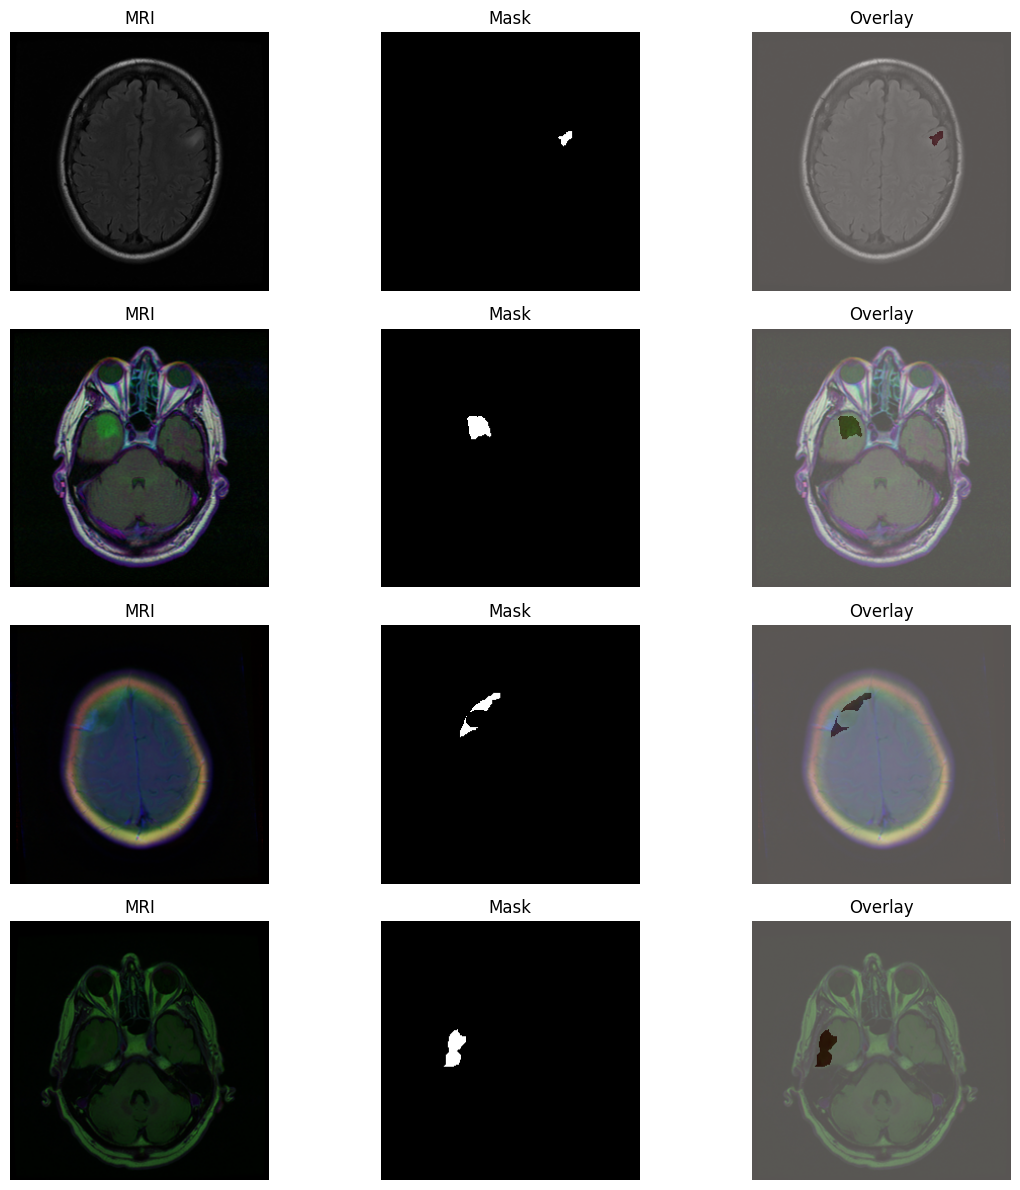

In [ ]:
def show_dataset_examples(n=4):
    idxs = random.sample(range(len(image_paths)), min(n, len(image_paths)))

    plt.figure(figsize=(12, 3*n))

    for row, idx in enumerate(idxs):
        image = cv2.imread(image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        plt.subplot(n, 3, row*3 + 1)
        plt.imshow(image)
        plt.title("MRI")
        plt.axis("off")

        plt.subplot(n, 3, row*3 + 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(n, 3, row*3 + 3)
        plt.imshow(image)
        plt.imshow(mask, cmap="Reds", alpha=0.35)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "dataset_examples.png", dpi=200)
    plt.show()

show_dataset_examples(4)


In [ ]:
IMG_SIZE = 256

train_transform_light = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=10, p=0.4),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2(),
])

train_transform_heavy = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.25),
    A.GaussianBlur(p=0.15),
    A.Normalize(),
    ToTensorV2(),
])

valid_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

no_aug_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])


In [ ]:

class BrainMRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"].float()
            mask = augmented["mask"].unsqueeze(0).float()

        return image, mask


def make_loader(imgs, masks, transform, batch_size=8, shuffle=False, num_workers=2):
    ds = BrainMRIDataset(imgs, masks, transform=transform)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )


In [ ]:
BATCH_SIZE = 8
NUM_WORKERS = 2

train_loader_light = make_loader(
    train_imgs,
    train_masks,
    train_transform_light,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

train_loader_heavy = make_loader(
    train_imgs,
    train_masks,
    train_transform_heavy,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

train_loader_no_aug = make_loader(
    train_imgs,
    train_masks,
    no_aug_transform,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = make_loader(
    val_imgs,
    val_masks,
    valid_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = make_loader(
    test_imgs,
    test_masks,
    valid_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


In [ ]:

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class VanillaUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []

        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i // 2]

            if x.shape[2:] != skip.shape[2:]:
                x = nn.functional.interpolate(
                    x,
                    size=skip.shape[2:],
                    mode="bilinear",
                    align_corners=False
                )

            x = torch.cat([skip, x], dim=1)
            x = self.ups[i + 1](x)

        return self.final(x)


In [ ]:

def build_model(model_name):
    if model_name == "vanilla_unet":
        return VanillaUNet().to(DEVICE)

    if model_name == "resnet34_unet":
        return smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        ).to(DEVICE)

    if model_name == "efficientnetb0_unet":
        return smp.Unet(
            encoder_name="efficientnet-b0",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        ).to(DEVICE)

    raise ValueError(f"Unknown model name: {model_name}")


In [ ]:

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(logits.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        denominator = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * intersection + self.smooth) / (denominator + self.smooth)
        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + self.dice_weight * self.dice(logits, targets)


class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(logits.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        tp = (probs * targets).sum(dim=1)
        fp = ((1 - targets) * probs).sum(dim=1)
        fn = (targets * (1 - probs)).sum(dim=1)

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth
        )

        return 1 - tversky.mean()


def get_loss(loss_name):
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss()
    if loss_name == "dice":
        return DiceLoss()
    if loss_name == "bce_dice":
        return BCEDiceLoss()
    if loss_name == "tversky":
        return TverskyLoss(alpha=0.3, beta=0.7)

    raise ValueError(loss_name)


In [ ]:
def compute_batch_metrics(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    tp = (preds_flat * targets_flat).sum(dim=1)
    fp = (preds_flat * (1 - targets_flat)).sum(dim=1)
    fn = ((1 - preds_flat) * targets_flat).sum(dim=1)

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return {
        "dice": dice.detach().cpu().numpy(),
        "iou": iou.detach().cpu().numpy(),
        "precision": precision.detach().cpu().numpy(),
        "recall": recall.detach().cpu().numpy(),
    }


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    losses = []

    for images, masks in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        if USE_AMP:
            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    losses = []
    all_metrics = {"dice": [], "iou": [], "precision": [], "recall": []}

    for images, masks in loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)
        loss = criterion(logits, masks)
        losses.append(loss.item())

        batch_metrics = compute_batch_metrics(logits, masks)

        for k in all_metrics:
            all_metrics[k].extend(batch_metrics[k])

    result = {k: float(np.mean(v)) for k, v in all_metrics.items()}
    result["loss"] = float(np.mean(losses))

    return result


In [ ]:

def train_resumable_experiment(
    experiment_name,
    model_name,
    loss_name,
    train_loader,
    val_loader,
    max_epochs=20,
    lr=1e-4,
    patience=5,
    resume=True
):
    exp_dir = CHECKPOINT_DIR / experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)

    latest_path = exp_dir / "latest.pth"
    best_path = exp_dir / "best.pth"
    history_path = TABLE_DIR / f"{experiment_name}_history.csv"
    summary_path = TABLE_DIR / f"{experiment_name}_summary.json"

    model = build_model(model_name)
    criterion = get_loss(loss_name)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler() if USE_AMP else None

    start_epoch = 1
    best_dice = -1.0
    no_improve = 0
    history = []

    if resume and latest_path.exists():
        print("Resuming from:", latest_path)
        checkpoint = torch.load(latest_path, map_location=DEVICE)

        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])

        if USE_AMP and checkpoint.get("scaler_state") is not None:
            scaler.load_state_dict(checkpoint["scaler_state"])

        start_epoch = checkpoint["epoch"] + 1
        best_dice = checkpoint["best_dice"]
        no_improve = checkpoint.get("no_improve", 0)

        if history_path.exists():
            history = pd.read_csv(history_path).to_dict("records")

        print(f"Starting from epoch {start_epoch}. Best Dice so far: {best_dice:.4f}")
    else:
        print("Starting new experiment:", experiment_name)

    start_time = time.time()

    for epoch in range(start_epoch, max_epochs + 1):
        epoch_start = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_metrics = evaluate(model, val_loader, criterion)

        epoch_time = time.time() - epoch_start

        row = {
            "experiment": experiment_name,
            "model": model_name,
            "loss": loss_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "epoch_time_sec": epoch_time
        }

        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        improved = val_metrics["dice"] > best_dice

        if improved:
            best_dice = val_metrics["dice"]
            no_improve = 0

            torch.save({
                "epoch": epoch,
                "model_name": model_name,
                "loss_name": loss_name,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scaler_state": scaler.state_dict() if USE_AMP else None,
                "best_dice": best_dice,
                "no_improve": no_improve,
                "history": history
            }, best_path)
        else:
            no_improve += 1

        # Always save latest checkpoint after every epoch.
        torch.save({
            "epoch": epoch,
            "model_name": model_name,
            "loss_name": loss_name,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict() if USE_AMP else None,
            "best_dice": best_dice,
            "no_improve": no_improve,
            "history": history
        }, latest_path)

        summary = {
            "experiment": experiment_name,
            "model": model_name,
            "loss": loss_name,
            "latest_epoch": epoch,
            "best_dice": best_dice,
            "latest_val_dice": val_metrics["dice"],
            "latest_val_iou": val_metrics["iou"],
            "latest_val_precision": val_metrics["precision"],
            "latest_val_recall": val_metrics["recall"],
            "best_checkpoint": str(best_path),
            "latest_checkpoint": str(latest_path)
        }

        with open(summary_path, "w") as f:
            json.dump(summary, f, indent=2)

        print(
            f"{experiment_name} | Epoch {epoch}/{max_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_dice={val_metrics['dice']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f} | "
            f"val_recall={val_metrics['recall']:.4f} | "
            f"{'BEST' if improved else ''}"
        )

        if no_improve >= patience:
            print(f"Early stopping triggered after {patience} non-improving epochs.")
            break

    total_time = time.time() - start_time

    print("Training complete.")
    print("Best checkpoint:", best_path)
    print("Latest checkpoint:", latest_path)
    print("History CSV:", history_path)
    print("Best validation Dice:", best_dice)

    return model, pd.DataFrame(history)


In [ ]:

def load_best_model(experiment_name):
    exp_dir = CHECKPOINT_DIR / experiment_name
    best_path = exp_dir / "best.pth"

    assert best_path.exists(), f"Best checkpoint not found: {best_path}"

    checkpoint = torch.load(best_path, map_location=DEVICE)

    model = build_model(checkpoint["model_name"])
    model.load_state_dict(checkpoint["model_state"])
    model.to(DEVICE)
    model.eval()

    loss_name = checkpoint["loss_name"]

    print("Loaded:", experiment_name)
    print("Model:", checkpoint["model_name"])
    print("Loss:", loss_name)
    print("Best Dice:", checkpoint["best_dice"])

    return model, checkpoint["model_name"], loss_name


###  EXPERIMENT 1: Vanilla U-Net + BCE-Dice Baseline

In [ ]:
EXPERIMENT_NAME = "exp1_vanilla_unet_bce_dice"
MODEL_NAME = "vanilla_unet"
LOSS_NAME = "bce_dice"
MAX_EPOCHS = 15
RESUME = True

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_light,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=5,
    resume=RESUME
)

history.tail()


Starting new experiment: exp1_vanilla_unet_bce_dice


exp1_vanilla_unet_bce_dice | Epoch 1/15 | train_loss=0.7129 | val_dice=0.4991 | val_iou=0.3885 | val_recall=0.7243 | BEST


exp1_vanilla_unet_bce_dice | Epoch 2/15 | train_loss=0.6382 | val_dice=0.5936 | val_iou=0.5017 | val_recall=0.6232 | BEST


exp1_vanilla_unet_bce_dice | Epoch 3/15 | train_loss=0.6082 | val_dice=0.6609 | val_iou=0.5537 | val_recall=0.7860 | BEST


exp1_vanilla_unet_bce_dice | Epoch 4/15 | train_loss=0.5807 | val_dice=0.6689 | val_iou=0.5587 | val_recall=0.8236 | BEST


...

exp1_vanilla_unet_bce_dice | Epoch 12/15 | train_loss=0.3799 | val_dice=0.7810 | val_iou=0.6782 | val_recall=0.8667 | BEST


exp1_vanilla_unet_bce_dice | Epoch 13/15 | train_loss=0.3591 | val_dice=0.7618 | val_iou=0.6601 | val_recall=0.9196 | 


exp1_vanilla_unet_bce_dice | Epoch 14/15 | train_loss=0.3331 | val_dice=0.7855 | val_iou=0.6875 | val_recall=0.9165 | BEST


exp1_vanilla_unet_bce_dice | Epoch 15/15 | train_loss=0.3138 | val_dice=0.7580 | val_iou=0.6580 | val_recall=0.9053 | 
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp1_vanilla_unet_bce_dice/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp1_vanilla_unet_bce_dice/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/exp1_vanilla_unet_bce_dice_history.csv
Best validation Dice: 0.7854549288749695


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
10,exp1_vanilla_unet_bce_dice,vanilla_unet,bce_dice,11,0.401657,0.388832,0.756089,0.652625,0.703382,0.919216,21.726923
11,exp1_vanilla_unet_bce_dice,vanilla_unet,bce_dice,12,0.379885,0.350889,0.781043,0.678195,0.770344,0.866697,21.554302
12,exp1_vanilla_unet_bce_dice,vanilla_unet,bce_dice,13,0.359127,0.348932,0.761810,0.660141,0.694722,0.919584,22.910386
13,exp1_vanilla_unet_bce_dice,vanilla_unet,bce_dice,14,0.333051,0.313325,0.785455,0.687475,0.737673,0.916513,22.054459
14,exp1_vanilla_unet_bce_dice,vanilla_unet,bce_dice,15,0.313838,0.301468,0.757958,0.658016,0.710586,0.905261,21.386927


### EXPERIMENT 2: ResNet34 U-Net + BCE-Dice

In [ ]:
EXPERIMENT_NAME = "exp2_resnet34_unet_bce_dice"
MODEL_NAME = "resnet34_unet"
LOSS_NAME = "bce_dice"
MAX_EPOCHS = 20
RESUME = False

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_light,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=5,
    resume=RESUME
)

history.tail()


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Starting new experiment: exp2_resnet34_unet_bce_dice


exp2_resnet34_unet_bce_dice | Epoch 1/20 | train_loss=0.7084 | val_dice=0.5882 | val_iou=0.4691 | val_recall=0.7460 | BEST


exp2_resnet34_unet_bce_dice | Epoch 2/20 | train_loss=0.5134 | val_dice=0.6239 | val_iou=0.4831 | val_recall=0.9106 | BEST


...

exp2_resnet34_unet_bce_dice | Epoch 17/20 | train_loss=0.1050 | val_dice=0.8208 | val_iou=0.7370 | val_recall=0.8460 | 


exp2_resnet34_unet_bce_dice | Epoch 18/20 | train_loss=0.0956 | val_dice=0.8383 | val_iou=0.7542 | val_recall=0.8749 | BEST


exp2_resnet34_unet_bce_dice | Epoch 19/20 | train_loss=0.0940 | val_dice=0.8345 | val_iou=0.7528 | val_recall=0.8855 | 


exp2_resnet34_unet_bce_dice | Epoch 20/20 | train_loss=0.0882 | val_dice=0.8493 | val_iou=0.7657 | val_recall=0.8791 | BEST
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp2_resnet34_unet_bce_dice/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp2_resnet34_unet_bce_dice/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/exp2_resnet34_unet_bce_dice_history.csv
Best validation Dice: 0.8493117690086365


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
15,exp2_resnet34_unet_bce_dice,resnet34_unet,bce_dice,16,0.105812,0.113800,0.819176,0.736016,0.838217,0.857758,21.137307
16,exp2_resnet34_unet_bce_dice,resnet34_unet,bce_dice,17,0.105015,0.111646,0.820838,0.736996,0.850760,0.846006,22.172055
17,exp2_resnet34_unet_bce_dice,resnet34_unet,bce_dice,18,0.095602,0.099865,0.838318,0.754162,0.843404,0.874878,21.111370
18,exp2_resnet34_unet_bce_dice,resnet34_unet,bce_dice,19,0.093999,0.101332,0.834514,0.752750,0.817453,0.885524,22.231747
19,exp2_resnet34_unet_bce_dice,resnet34_unet,bce_dice,20,0.088156,0.093515,0.849312,0.765749,0.852292,0.879129,20.884365


###  EXPERIMENT 3: ResNet34 U-Net + Tversky

In [ ]:
EXPERIMENT_NAME = "exp3_resnet34_unet_tversky"
MODEL_NAME = "resnet34_unet"
LOSS_NAME = "tversky"
MAX_EPOCHS = 20
RESUME = True

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_light,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=5,
    resume=RESUME
)

history.tail()


Starting new experiment: exp3_resnet34_unet_tversky


exp3_resnet34_unet_tversky | Epoch 1/20 | train_loss=0.7883 | val_dice=0.3914 | val_iou=0.3001 | val_recall=0.9897 | BEST


exp3_resnet34_unet_tversky | Epoch 2/20 | train_loss=0.6745 | val_dice=0.4664 | val_iou=0.3920 | val_recall=0.9770 | BEST


exp3_resnet34_unet_tversky | Epoch 3/20 | train_loss=0.6157 | val_dice=0.5638 | val_iou=0.4749 | val_recall=0.9557 | BEST


exp3_resnet34_unet_tversky | Epoch 4/20 | train_loss=0.5713 | val_dice=0.4838 | val_iou=0.4128 | val_recall=0.9818 | 


...

exp3_resnet34_unet_tversky | Epoch 17/20 | train_loss=0.1665 | val_dice=0.8094 | val_iou=0.7236 | val_recall=0.8791 | 


exp3_resnet34_unet_tversky | Epoch 18/20 | train_loss=0.1578 | val_dice=0.8233 | val_iou=0.7329 | val_recall=0.9261 | BEST


exp3_resnet34_unet_tversky | Epoch 19/20 | train_loss=0.1704 | val_dice=0.8051 | val_iou=0.7184 | val_recall=0.8791 | 


exp3_resnet34_unet_tversky | Epoch 20/20 | train_loss=0.1557 | val_dice=0.8194 | val_iou=0.7275 | val_recall=0.9002 | 
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp3_resnet34_unet_tversky/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp3_resnet34_unet_tversky/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/exp3_resnet34_unet_tversky_history.csv
Best validation Dice: 0.8232571482658386


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
15,exp3_resnet34_unet_tversky,resnet34_unet,tversky,16,0.179554,0.182018,0.804614,0.713348,0.749650,0.919960,20.994267
16,exp3_resnet34_unet_tversky,resnet34_unet,tversky,17,0.166504,0.182712,0.809379,0.723588,0.808804,0.879058,21.899716
17,exp3_resnet34_unet_tversky,resnet34_unet,tversky,18,0.157811,0.156937,0.823257,0.732949,0.774009,0.926141,20.639171
18,exp3_resnet34_unet_tversky,resnet34_unet,tversky,19,0.170423,0.179941,0.805095,0.718407,0.779380,0.879052,20.798652
19,exp3_resnet34_unet_tversky,resnet34_unet,tversky,20,0.155733,0.163499,0.819358,0.727549,0.801978,0.900158,21.638223


### EXPERIMENT 4: EfficientNet-B0 U-Net + BCE-Dice

In [ ]:
EXPERIMENT_NAME = "exp4_efficientnetb0_unet_bce_dice"
MODEL_NAME = "efficientnetb0_unet"
LOSS_NAME = "bce_dice"
MAX_EPOCHS = 20
RESUME = False

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_light,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=5,
    resume=RESUME
)

history.tail()


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Starting new experiment: exp4_efficientnetb0_unet_bce_dice


exp4_efficientnetb0_unet_bce_dice | Epoch 1/20 | train_loss=0.6798 | val_dice=0.6021 | val_iou=0.4817 | val_recall=0.7527 | BEST


exp4_efficientnetb0_unet_bce_dice | Epoch 2/20 | train_loss=0.5192 | val_dice=0.7223 | val_iou=0.6084 | val_recall=0.8846 | BEST


...

exp4_efficientnetb0_unet_bce_dice | Epoch 17/20 | train_loss=0.0897 | val_dice=0.8348 | val_iou=0.7468 | val_recall=0.9169 | 


exp4_efficientnetb0_unet_bce_dice | Epoch 18/20 | train_loss=0.0859 | val_dice=0.8441 | val_iou=0.7565 | val_recall=0.8410 | 


exp4_efficientnetb0_unet_bce_dice | Epoch 19/20 | train_loss=0.0823 | val_dice=0.8446 | val_iou=0.7613 | val_recall=0.8817 | 


exp4_efficientnetb0_unet_bce_dice | Epoch 20/20 | train_loss=0.0809 | val_dice=0.8538 | val_iou=0.7700 | val_recall=0.8820 | BEST
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp4_efficientnetb0_unet_bce_dice/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp4_efficientnetb0_unet_bce_dice/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/exp4_efficientnetb0_unet_bce_dice_history.csv
Best validation Dice: 0.8538411259651184


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
15,exp4_efficientnetb0_unet_bce_dice,efficientnetb0_unet,bce_dice,16,0.089630,0.096267,0.848403,0.763460,0.862190,0.870119,24.068500
16,exp4_efficientnetb0_unet_bce_dice,efficientnetb0_unet,bce_dice,17,0.089653,0.103223,0.834804,0.746770,0.791428,0.916870,21.792980
17,exp4_efficientnetb0_unet_bce_dice,efficientnetb0_unet,bce_dice,18,0.085868,0.097161,0.844127,0.756545,0.878389,0.840955,23.668866
18,exp4_efficientnetb0_unet_bce_dice,efficientnetb0_unet,bce_dice,19,0.082284,0.094812,0.844627,0.761316,0.843934,0.881703,22.311404
19,exp4_efficientnetb0_unet_bce_dice,efficientnetb0_unet,bce_dice,20,0.080927,0.090697,0.853841,0.770025,0.849690,0.882012,23.506612


### EXPERIMENT 5: ResNet34 U-Net + Dice Loss

In [ ]:
EXPERIMENT_NAME = "exp5_resnet34_unet_dice"
MODEL_NAME = "resnet34_unet"
LOSS_NAME = "dice"
MAX_EPOCHS = 15
RESUME = True

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_light,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=5,
    resume=RESUME
)

history.tail()


Starting new experiment: exp5_resnet34_unet_dice


exp5_resnet34_unet_dice | Epoch 1/15 | train_loss=0.8504 | val_dice=0.3308 | val_iou=0.2785 | val_recall=0.9687 | BEST


exp5_resnet34_unet_dice | Epoch 2/15 | train_loss=0.6813 | val_dice=0.4347 | val_iou=0.3764 | val_recall=0.9286 | BEST


exp5_resnet34_unet_dice | Epoch 3/15 | train_loss=0.5772 | val_dice=0.4393 | val_iou=0.3889 | val_recall=0.9588 | BEST


exp5_resnet34_unet_dice | Epoch 4/15 | train_loss=0.5242 | val_dice=0.5762 | val_iou=0.5055 | val_recall=0.9077 | BEST


...

exp5_resnet34_unet_dice | Epoch 12/15 | train_loss=0.2151 | val_dice=0.8175 | val_iou=0.7266 | val_recall=0.8542 | BEST


exp5_resnet34_unet_dice | Epoch 13/15 | train_loss=0.1935 | val_dice=0.8131 | val_iou=0.7250 | val_recall=0.8561 | 


exp5_resnet34_unet_dice | Epoch 14/15 | train_loss=0.1862 | val_dice=0.8200 | val_iou=0.7319 | val_recall=0.8395 | BEST


exp5_resnet34_unet_dice | Epoch 15/15 | train_loss=0.1791 | val_dice=0.8203 | val_iou=0.7365 | val_recall=0.8848 | BEST
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp5_resnet34_unet_dice/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp5_resnet34_unet_dice/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/exp5_resnet34_unet_dice_history.csv
Best validation Dice: 0.8202916383743286


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
10,exp5_resnet34_unet_dice,resnet34_unet,dice,11,0.210608,0.215458,0.797502,0.714890,0.833871,0.857085,22.185813
11,exp5_resnet34_unet_dice,resnet34_unet,dice,12,0.215102,0.193451,0.817534,0.726621,0.822430,0.854214,40.356441
12,exp5_resnet34_unet_dice,resnet34_unet,dice,13,0.193489,0.193886,0.813104,0.724977,0.831814,0.856147,27.606607
13,exp5_resnet34_unet_dice,resnet34_unet,dice,14,0.186182,0.186448,0.819958,0.731886,0.831986,0.839548,21.407034
14,exp5_resnet34_unet_dice,resnet34_unet,dice,15,0.179124,0.183848,0.820292,0.736500,0.817861,0.884786,27.013889


### Best Model + No Augmentation

In [ ]:
EXPERIMENT_NAME = "abl_no_aug_resnet34_bce_dice"
MODEL_NAME = "resnet34_unet"
LOSS_NAME = "bce_dice"
MAX_EPOCHS = 12
RESUME = True

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_no_aug,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=4,
    resume=RESUME
)

history.tail()


Starting new experiment: abl_no_aug_resnet34_bce_dice


abl_no_aug_resnet34_bce_dice | Epoch 1/12 | train_loss=0.5449 | val_dice=0.6418 | val_iou=0.5320 | val_recall=0.7877 | BEST


abl_no_aug_resnet34_bce_dice | Epoch 2/12 | train_loss=0.3910 | val_dice=0.7386 | val_iou=0.6317 | val_recall=0.9183 | BEST


abl_no_aug_resnet34_bce_dice | Epoch 3/12 | train_loss=0.2996 | val_dice=0.7854 | val_iou=0.6901 | val_recall=0.8670 | BEST


abl_no_aug_resnet34_bce_dice | Epoch 4/12 | train_loss=0.2292 | val_dice=0.7809 | val_iou=0.6825 | val_recall=0.9082 | 


...

abl_no_aug_resnet34_bce_dice | Epoch 9/12 | train_loss=0.0963 | val_dice=0.8168 | val_iou=0.7294 | val_recall=0.9105 | 


abl_no_aug_resnet34_bce_dice | Epoch 10/12 | train_loss=0.0865 | val_dice=0.8334 | val_iou=0.7441 | val_recall=0.8241 | 


abl_no_aug_resnet34_bce_dice | Epoch 11/12 | train_loss=0.0754 | val_dice=0.8362 | val_iou=0.7515 | val_recall=0.8409 | BEST


abl_no_aug_resnet34_bce_dice | Epoch 12/12 | train_loss=0.0732 | val_dice=0.8387 | val_iou=0.7546 | val_recall=0.8640 | BEST
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/abl_no_aug_resnet34_bce_dice/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/abl_no_aug_resnet34_bce_dice/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/abl_no_aug_resnet34_bce_dice_history.csv
Best validation Dice: 0.8387274742126465


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
7,abl_no_aug_resnet34_bce_dice,resnet34_unet,bce_dice,8,0.101809,0.113790,0.836217,0.750808,0.842802,0.873945,26.475708
8,abl_no_aug_resnet34_bce_dice,resnet34_unet,bce_dice,9,0.096299,0.117012,0.816771,0.729420,0.780764,0.910531,40.576666
9,abl_no_aug_resnet34_bce_dice,resnet34_unet,bce_dice,10,0.086452,0.106585,0.833377,0.744130,0.872677,0.824108,27.258988
10,abl_no_aug_resnet34_bce_dice,resnet34_unet,bce_dice,11,0.075368,0.104138,0.836240,0.751472,0.872630,0.840897,36.894238
11,abl_no_aug_resnet34_bce_dice,resnet34_unet,bce_dice,12,0.073225,0.101953,0.838727,0.754638,0.859216,0.864039,33.098593


### Best Model + Heavy Augmentation

In [ ]:
EXPERIMENT_NAME = "abl_heavy_aug_resnet34_bce_dice"
MODEL_NAME = "resnet34_unet"
LOSS_NAME = "bce_dice"
MAX_EPOCHS = 12
RESUME = True

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_heavy,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=4,
    resume=RESUME
)

history.tail()


Starting new experiment: abl_heavy_aug_resnet34_bce_dice


abl_heavy_aug_resnet34_bce_dice | Epoch 1/12 | train_loss=0.5956 | val_dice=0.6279 | val_iou=0.5170 | val_recall=0.8749 | BEST


abl_heavy_aug_resnet34_bce_dice | Epoch 2/12 | train_loss=0.4407 | val_dice=0.7259 | val_iou=0.6158 | val_recall=0.8593 | BEST


abl_heavy_aug_resnet34_bce_dice | Epoch 3/12 | train_loss=0.3516 | val_dice=0.7534 | val_iou=0.6500 | val_recall=0.8560 | BEST


abl_heavy_aug_resnet34_bce_dice | Epoch 4/12 | train_loss=0.2865 | val_dice=0.7556 | val_iou=0.6479 | val_recall=0.9042 | BEST


...

abl_heavy_aug_resnet34_bce_dice | Epoch 9/12 | train_loss=0.1556 | val_dice=0.8152 | val_iou=0.7277 | val_recall=0.8623 | BEST


abl_heavy_aug_resnet34_bce_dice | Epoch 10/12 | train_loss=0.1566 | val_dice=0.8086 | val_iou=0.7157 | val_recall=0.7980 | 


abl_heavy_aug_resnet34_bce_dice | Epoch 11/12 | train_loss=0.1470 | val_dice=0.8214 | val_iou=0.7312 | val_recall=0.8369 | BEST


abl_heavy_aug_resnet34_bce_dice | Epoch 12/12 | train_loss=0.1406 | val_dice=0.8263 | val_iou=0.7360 | val_recall=0.8633 | BEST
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/abl_heavy_aug_resnet34_bce_dice/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/abl_heavy_aug_resnet34_bce_dice/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/abl_heavy_aug_resnet34_bce_dice_history.csv
Best validation Dice: 0.8263394832611084


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
7,abl_heavy_aug_resnet34_bce_dice,resnet34_unet,bce_dice,8,0.171535,0.127319,0.815188,0.726442,0.819224,0.858016,39.583864
8,abl_heavy_aug_resnet34_bce_dice,resnet34_unet,bce_dice,9,0.155583,0.121172,0.815191,0.727672,0.814297,0.862262,41.616640
9,abl_heavy_aug_resnet34_bce_dice,resnet34_unet,bce_dice,10,0.156619,0.124332,0.808646,0.715683,0.862195,0.797958,45.473973
10,abl_heavy_aug_resnet34_bce_dice,resnet34_unet,bce_dice,11,0.146964,0.113676,0.821367,0.731241,0.850366,0.836897,36.602685
11,abl_heavy_aug_resnet34_bce_dice,resnet34_unet,bce_dice,12,0.140570,0.110087,0.826339,0.735967,0.823989,0.863314,30.834550


In [ ]:
summary_files = sorted(TABLE_DIR.glob("*_summary.json"))

summaries = []

for f in summary_files:
    with open(f, "r") as fp:
        summaries.append(json.load(fp))

summary_df = pd.DataFrame(summaries)

if len(summary_df) > 0:
    summary_df = summary_df.sort_values("best_dice", ascending=False)
    summary_df.to_csv(TABLE_DIR / "all_experiment_summaries.csv", index=False)

summary_df


,experiment,model,loss,latest_epoch,best_dice,latest_val_dice,latest_val_iou,latest_val_precision,latest_val_recall,best_checkpoint,latest_checkpoint
5,exp4_efficientnetb0_unet_bce_dice,efficientnetb0_unet,bce_dice,20,0.853841,0.853841,0.770025,0.849690,0.882012,/content/drive/MyDrive/brain_tumor_segmentatio...,/content/drive/MyDrive/brain_tumor_segmentatio...
3,exp2_resnet34_unet_bce_dice,resnet34_unet,bce_dice,20,0.849312,0.849312,0.765749,0.852292,0.879129,/content/drive/MyDrive/brain_tumor_segmentatio...,/content/drive/MyDrive/brain_tumor_segmentatio...
1,abl_no_aug_resnet34_bce_dice,resnet34_unet,bce_dice,12,0.838727,0.838727,0.754638,0.859216,0.864039,/content/drive/MyDrive/brain_tumor_segmentatio...,/content/drive/MyDrive/brain_tumor_segmentatio...
0,abl_heavy_aug_resnet34_bce_dice,resnet34_unet,bce_dice,12,0.826339,0.826339,0.735967,0.823989,0.863314,/content/drive/MyDrive/brain_tumor_segmentatio...,/content/drive/MyDrive/brain_tumor_segmentatio...
4,exp3_resnet34_unet_tversky,resnet34_unet,tversky,20,0.823257,0.819358,0.727549,0.801978,0.900158,/content/drive/MyDrive/brain_tumor_segmentatio...,/content/drive/MyDrive/brain_tumor_segmentatio...
6,exp5_resnet34_unet_dice,resnet34_unet,dice,15,0.820292,0.820292,0.736500,0.817861,0.884786,/content/drive/MyDrive/brain_tumor_segmentatio...,/content/drive/MyDrive/brain_tumor_segmentatio...
2,exp1_vanilla_unet_bce_dice,vanilla_unet,bce_dice,15,0.785455,0.757958,0.658016,0.710586,0.905261,/content/drive/MyDrive/brain_tumor_segmentatio...,/content/drive/MyDrive/brain_tumor_segmentatio...


In [ ]:

def tumor_size_group(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    ratio = np.sum(mask > 0) / mask.size

    if ratio < 0.01:
        return "very_small"
    elif ratio < 0.05:
        return "small"
    elif ratio < 0.15:
        return "medium"
    else:
        return "large"


@torch.no_grad()
def evaluate_per_case(model, img_paths, m_paths):
    rows = []

    for img_path, mask_path in tqdm(list(zip(img_paths, m_paths))):
        ds = BrainMRIDataset([img_path], [mask_path], transform=valid_transform)
        image, mask = ds[0]

        image = image.unsqueeze(0).to(DEVICE)
        mask = mask.unsqueeze(0).to(DEVICE)

        logits = model(image)
        metrics = compute_batch_metrics(logits, mask)

        rows.append({
            "image": img_path,
            "mask": mask_path,
            "size_group": tumor_size_group(mask_path),
            "dice": float(metrics["dice"][0]),
            "iou": float(metrics["iou"][0]),
            "precision": float(metrics["precision"][0]),
            "recall": float(metrics["recall"][0]),
        })

    return pd.DataFrame(rows)


case_df = evaluate_per_case(best_model, test_imgs, test_masks)
case_df.to_csv(TABLE_DIR / "per_case_test_results.csv", index=False)

size_summary = case_df.groupby("size_group")[["dice", "iou", "precision", "recall"]].agg(["mean", "std", "count"])
size_summary.to_csv(TABLE_DIR / "tumor_size_summary.csv")

size_summary


100%|██████████| 206/206 [00:05<00:00, 34.55it/s]


dice                       iou                 precision  \
                mean       std count      mean       std count      mean   
size_group                                                                 
medium      0.922723  0.056985    46  0.861221  0.090739    46  0.939801   
small       0.893720  0.075729   117  0.815531  0.113384   117  0.894884   
very_small  0.673807  0.240202    43  0.548293  0.230802    43  0.689318   

                              recall                  
                 std count      mean       std count  
size_group                                            
medium      0.058111    46  0.913325  0.089308    46  
small       0.094326   117  0.903052  0.091705   117  
very_small  0.258086    43  0.750579  0.256477    43

In [ ]:

@torch.no_grad()
def predict_single(model, img_path, mask_path):
    image_raw = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB)

    mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask_binary = (mask_raw > 0).astype("float32")

    transformed = valid_transform(image=image_rgb, mask=mask_binary)

    image_tensor = transformed["image"].unsqueeze(0).to(DEVICE)

    logits = model(image_tensor)
    prob = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred = (prob > 0.5).astype("float32")

    resized_mask = cv2.resize(mask_binary, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    resized_image = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))

    error = np.abs(pred - resized_mask)

    return resized_image, resized_mask, prob, pred, error


def show_prediction_grid(model, img_paths, mask_paths, indices, save_name):
    n = len(indices)
    plt.figure(figsize=(16, 4*n))

    for row, idx in enumerate(indices):
        image, mask, prob, pred, error = predict_single(
            model,
            img_paths[idx],
            mask_paths[idx]
        )

        items = [
            (image, "MRI", None),
            (mask, "Ground Truth", "gray"),
            (prob, "Probability Map", "viridis"),
            (pred, "Prediction", "gray"),
            (error, "Error Map", "hot")
        ]

        for col, (arr, title, cmap) in enumerate(items):
            plt.subplot(n, 5, row*5 + col + 1)
            plt.imshow(arr, cmap=cmap)
            plt.title(title)
            plt.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / save_name, dpi=200)
    plt.show()


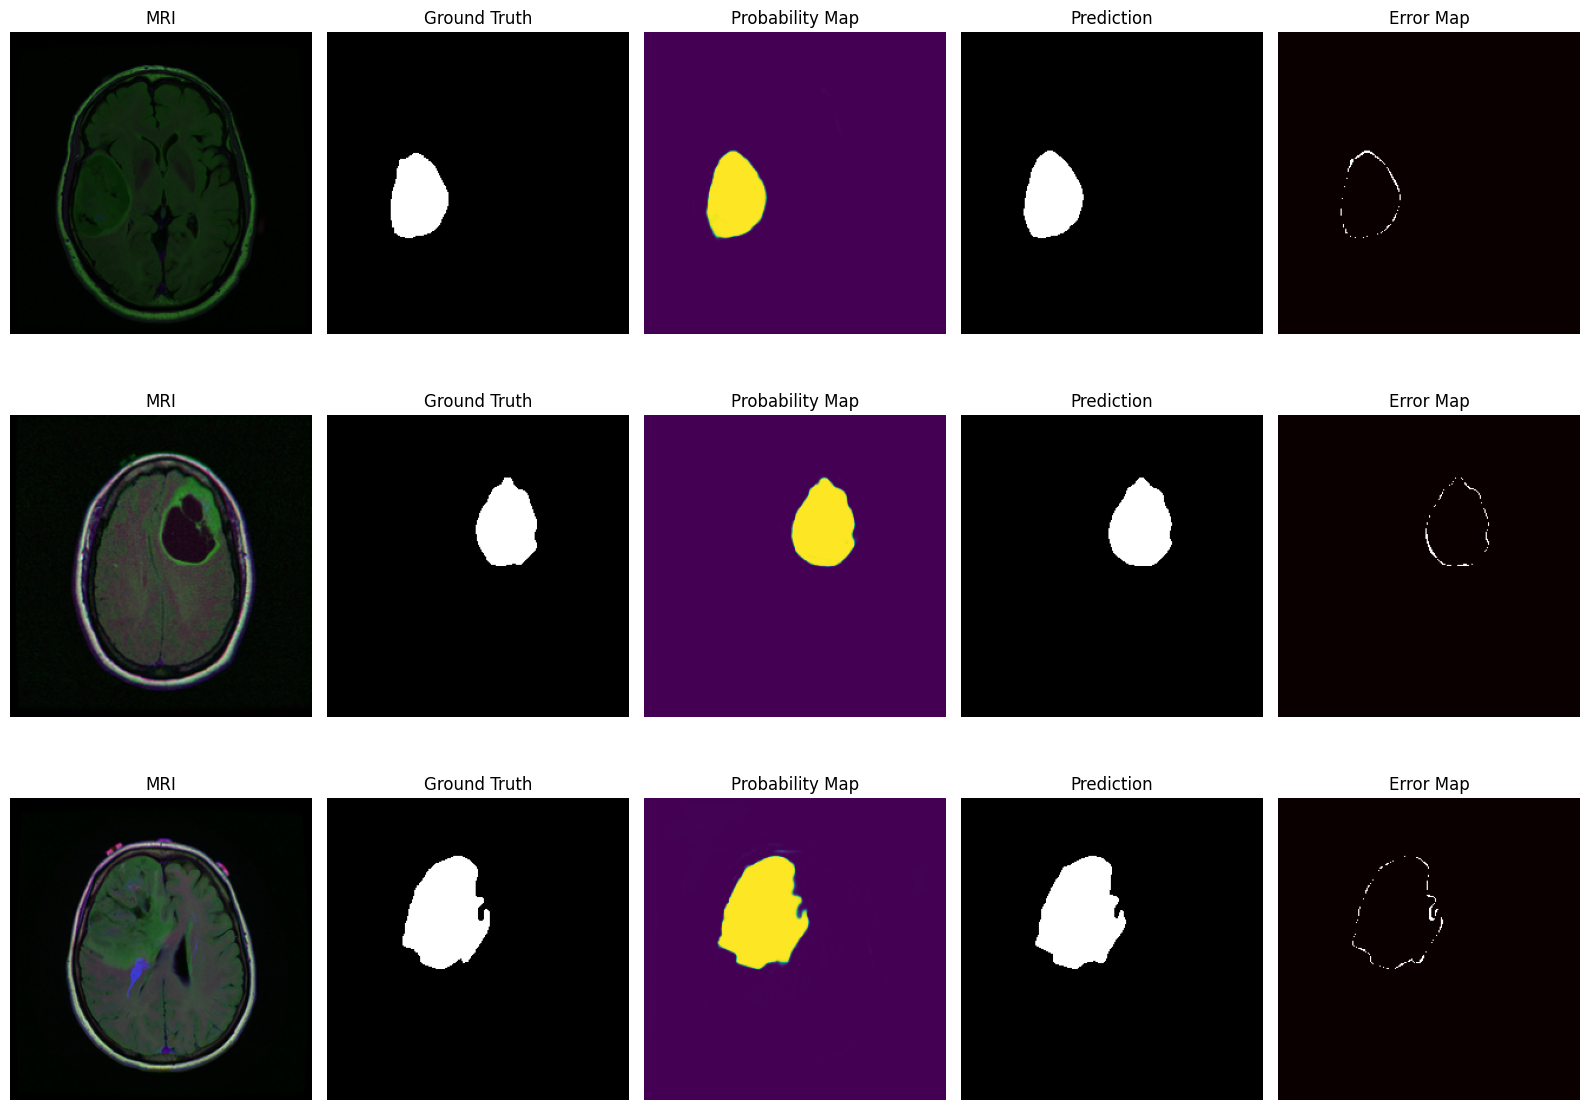

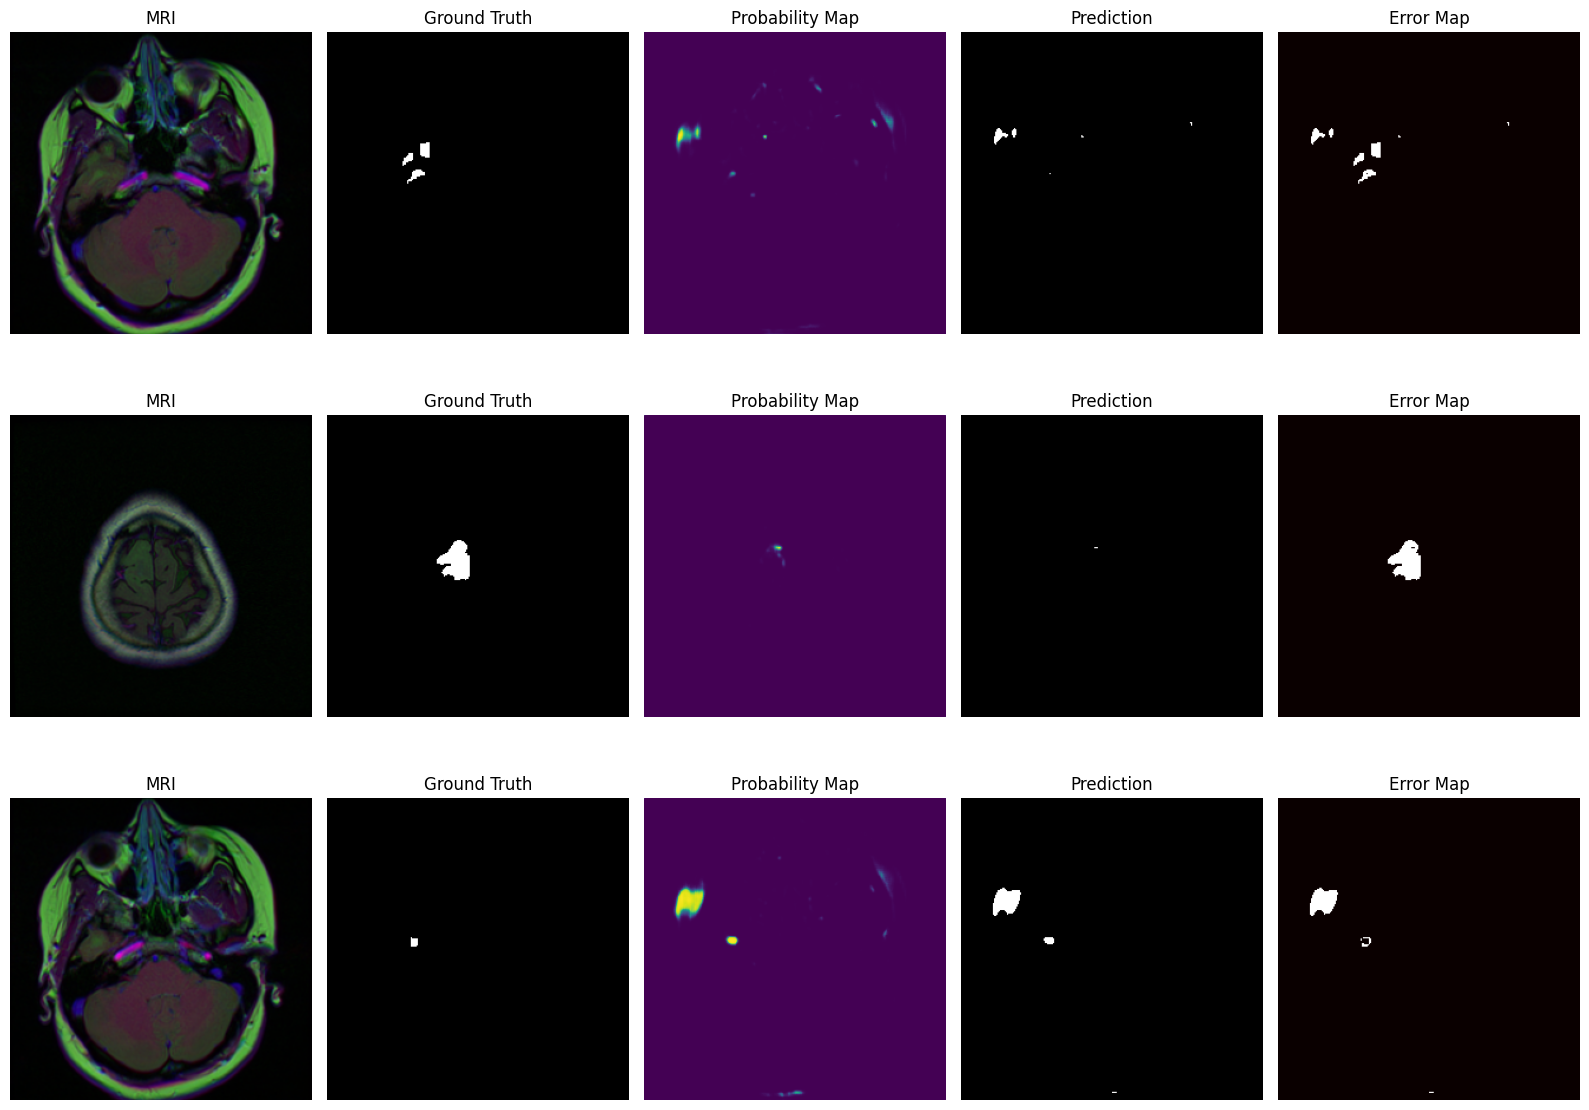

In [ ]:

sorted_cases = case_df.sort_values("dice")

worst_paths = sorted_cases.head(3)["image"].tolist()
best_paths = sorted_cases.tail(3)["image"].tolist()

worst_indices = [test_imgs.index(p) for p in worst_paths]
best_indices = [test_imgs.index(p) for p in best_paths]

show_prediction_grid(
    best_model,
    test_imgs,
    test_masks,
    best_indices,
    save_name="best_cases.png"
)

show_prediction_grid(
    best_model,
    test_imgs,
    test_masks,
    worst_indices,
    save_name="worst_cases.png"
)


In [ ]:
def categorize_failure(row):
    if row["recall"] < 0.40:
        return "missed_tumor"
    if row["precision"] < 0.40:
        return "false_positive_heavy"
    if row["dice"] < 0.60:
        return "boundary_or_partial_overlap"
    return "good_segmentation"


case_df["failure_category"] = case_df.apply(categorize_failure, axis=1)

failure_summary = case_df["failure_category"].value_counts().reset_index()
failure_summary.columns = ["failure_category", "count"]

failure_summary.to_csv(TABLE_DIR / "failure_category_summary.csv", index=False)

failure_summary


,failure_category,count
0,good_segmentation,194
1,missed_tumor,5
2,boundary_or_partial_overlap,4
3,false_positive_heavy,3


### ATTENTION U-NET

In [ ]:

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):


        if g.shape[2:] != x.shape[2:]:
            g = nn.functional.interpolate(
                g,
                size=x.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

       
        self.enc1 = DoubleConv(in_channels, features[0])
        self.enc2 = DoubleConv(features[0], features[1])
        self.enc3 = DoubleConv(features[1], features[2])
        self.enc4 = DoubleConv(features[2], features[3])

        
        self.bottleneck = DoubleConv(features[3], features[3] * 2)

       
        self.up4 = nn.ConvTranspose2d(features[3] * 2, features[3], kernel_size=2, stride=2)
        self.att4 = AttentionGate(F_g=features[3], F_l=features[3], F_int=features[2])
        self.dec4 = DoubleConv(features[3] * 2, features[3])

        self.up3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=features[2], F_l=features[2], F_int=features[1])
        self.dec3 = DoubleConv(features[2] * 2, features[2])

        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=features[1], F_l=features[1], F_int=features[0])
        self.dec2 = DoubleConv(features[1] * 2, features[1])

        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=features[0], F_l=features[0], F_int=features[0] // 2)
        self.dec1 = DoubleConv(features[0] * 2, features[0])

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        e4_att = self.att4(g=d4, x=e4)
        d4 = torch.cat((e4_att, d4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        e3_att = self.att3(g=d3, x=e3)
        d3 = torch.cat((e3_att, d3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        e2_att = self.att2(g=d2, x=e2)
        d2 = torch.cat((e2_att, d2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        e1_att = self.att1(g=d1, x=e1)
        d1 = torch.cat((e1_att, d1), dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

In [ ]:
def build_model(model_name):
    if model_name == "vanilla_unet":
        return VanillaUNet().to(DEVICE)

    if model_name == "attention_unet":
        return AttentionUNet().to(DEVICE)

    if model_name == "resnet34_unet":
        return smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        ).to(DEVICE)

    if model_name == "efficientnetb0_unet":
        return smp.Unet(
            encoder_name="efficientnet-b0",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        ).to(DEVICE)

    raise ValueError(f"Unknown model name: {model_name}")

In [ ]:

EXPERIMENT_NAME = "exp6_attention_unet_bce_dice"
MODEL_NAME = "attention_unet"
LOSS_NAME = "bce_dice"
MAX_EPOCHS = 20
RESUME = True

model, history = train_resumable_experiment(
    experiment_name=EXPERIMENT_NAME,
    model_name=MODEL_NAME,
    loss_name=LOSS_NAME,
    train_loader=train_loader_light,
    val_loader=val_loader,
    max_epochs=MAX_EPOCHS,
    lr=1e-4,
    patience=8,
    resume=RESUME
)

history.tail()

Starting new experiment: exp6_attention_unet_bce_dice


exp6_attention_unet_bce_dice | Epoch 1/20 | train_loss=0.6368 | val_dice=0.5941 | val_iou=0.4845 | val_recall=0.7274 | BEST


exp6_attention_unet_bce_dice | Epoch 2/20 | train_loss=0.5807 | val_dice=0.5240 | val_iou=0.3989 | val_recall=0.8384 | 


exp6_attention_unet_bce_dice | Epoch 3/20 | train_loss=0.5487 | val_dice=0.6029 | val_iou=0.4911 | val_recall=0.7771 | BEST


exp6_attention_unet_bce_dice | Epoch 4/20 | train_loss=0.5218 | val_dice=0.6814 | val_iou=0.5653 | val_recall=0.8587 | BEST


...

exp6_attention_unet_bce_dice | Epoch 17/20 | train_loss=0.2243 | val_dice=0.7967 | val_iou=0.7002 | val_recall=0.8677 | 


exp6_attention_unet_bce_dice | Epoch 18/20 | train_loss=0.2066 | val_dice=0.8029 | val_iou=0.7100 | val_recall=0.8879 | 


exp6_attention_unet_bce_dice | Epoch 19/20 | train_loss=0.1949 | val_dice=0.8116 | val_iou=0.7196 | val_recall=0.8767 | BEST


exp6_attention_unet_bce_dice | Epoch 20/20 | train_loss=0.1882 | val_dice=0.8116 | val_iou=0.7220 | val_recall=0.8746 | BEST
Training complete.
Best checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp6_attention_unet_bce_dice/best.pth
Latest checkpoint: /content/drive/MyDrive/brain_tumor_segmentation_project/checkpoints/exp6_attention_unet_bce_dice/latest.pth
History CSV: /content/drive/MyDrive/brain_tumor_segmentation_project/tables/exp6_attention_unet_bce_dice_history.csv
Best validation Dice: 0.8116421103477478


,experiment,model,loss,epoch,train_loss,val_loss,val_dice,val_iou,val_precision,val_recall,epoch_time_sec
15,exp6_attention_unet_bce_dice,attention_unet,bce_dice,16,0.244490,0.227215,0.806671,0.715318,0.829673,0.853373,25.362763
16,exp6_attention_unet_bce_dice,attention_unet,bce_dice,17,0.224341,0.214303,0.796663,0.700197,0.787300,0.867676,25.245639
17,exp6_attention_unet_bce_dice,attention_unet,bce_dice,18,0.206640,0.197629,0.802920,0.710047,0.780573,0.887861,22.676939
18,exp6_attention_unet_bce_dice,attention_unet,bce_dice,19,0.194945,0.189042,0.811625,0.719553,0.815690,0.876681,23.092046
19,exp6_attention_unet_bce_dice,attention_unet,bce_dice,20,0.188224,0.173844,0.811642,0.722046,0.805879,0.874566,24.332397


In [ ]:
!unzip -q \
/content/drive/MyDrive/brain_tumor_segmentation_project/dataset2/brisc2025.zip \
-d /content/

In [ ]:
BRISC_ROOT = "/content/brisc2025/segmentation_task"

BRISC_TRAIN_IMAGE_DIR = f"{BRISC_ROOT}/train/images"
BRISC_TRAIN_MASK_DIR  = f"{BRISC_ROOT}/train/masks"

BRISC_TEST_IMAGE_DIR = f"{BRISC_ROOT}/test/images"
BRISC_TEST_MASK_DIR  = f"{BRISC_ROOT}/test/masks"

print(BRISC_TRAIN_IMAGE_DIR)
print(BRISC_TRAIN_MASK_DIR)
print(BRISC_TEST_IMAGE_DIR)
print(BRISC_TEST_MASK_DIR)

/content/brisc2025/segmentation_task/train/images
/content/brisc2025/segmentation_task/train/masks
/content/brisc2025/segmentation_task/test/images
/content/brisc2025/segmentation_task/test/masks


In [ ]:
import os, glob

BRISC_ROOT = "/content/brisc2025/segmentation_task"

for folder in [
    "train/images", "train/masks",
    "test/images", "test/masks"
]:
    path = os.path.join(BRISC_ROOT, folder)
    files = glob.glob(path + "/*")
    print(folder, len(files))
    print(files[:5])

train/images 3933
['/content/brisc2025/segmentation_task/train/images/brisc2025_train_00436_gl_co_t1.jpg', '/content/brisc2025/segmentation_task/train/images/brisc2025_train_04730_pi_sa_t1.jpg', '/content/brisc2025/segmentation_task/train/images/brisc2025_train_00995_gl_sa_t1.jpg', '/content/brisc2025/segmentation_task/train/images/brisc2025_train_04155_pi_co_t1.jpg', '/content/brisc2025/segmentation_task/train/images/brisc2025_train_01862_me_co_t1.jpg']
train/masks 3933
['/content/brisc2025/segmentation_task/train/masks/brisc2025_train_00955_gl_sa_t1.png', '/content/brisc2025/segmentation_task/train/masks/brisc2025_train_02397_me_sa_t1.png', '/content/brisc2025/segmentation_task/train/masks/brisc2025_train_00832_gl_sa_t1.png', '/content/brisc2025/segmentation_task/train/masks/brisc2025_train_02275_me_sa_t1.png', '/content/brisc2025/segmentation_task/train/masks/brisc2025_train_04186_pi_co_t1.png']
test/images 860
['/content/brisc2025/segmentation_task/test/images/brisc2025_test_00264_

In [ ]:
import os, glob

BRISC_ROOT = "/content/brisc2025/segmentation_task"

BRISC_TRAIN_IMAGE_DIR = f"{BRISC_ROOT}/train/images"
BRISC_TRAIN_MASK_DIR  = f"{BRISC_ROOT}/train/masks"

BRISC_TEST_IMAGE_DIR = f"{BRISC_ROOT}/test/images"
BRISC_TEST_MASK_DIR  = f"{BRISC_ROOT}/test/masks"


def load_brisc_pairs(image_dir, mask_dir):
    image_paths = sorted(glob.glob(os.path.join(image_dir, "*.*")))
    mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.*")))

    image_map = {
        os.path.splitext(os.path.basename(p))[0]: p
        for p in image_paths
    }

    mask_map = {
        os.path.splitext(os.path.basename(p))[0]: p
        for p in mask_paths
    }

    common_names = sorted(set(image_map.keys()) & set(mask_map.keys()))

    paired_images = [image_map[name] for name in common_names]
    paired_masks = [mask_map[name] for name in common_names]

    print("Image files:", len(image_paths))
    print("Mask files:", len(mask_paths))
    print("Matched pairs:", len(paired_images))

    if len(paired_images) > 0:
        print("Example image:", paired_images[0])
        print("Example mask:", paired_masks[0])

    return paired_images, paired_masks


brisc_train_imgs, brisc_train_masks = load_brisc_pairs(
    BRISC_TRAIN_IMAGE_DIR,
    BRISC_TRAIN_MASK_DIR
)

brisc_test_imgs, brisc_test_masks = load_brisc_pairs(
    BRISC_TEST_IMAGE_DIR,
    BRISC_TEST_MASK_DIR
)

Image files: 3933
Mask files: 3933
Matched pairs: 3933
Example image: /content/brisc2025/segmentation_task/train/images/brisc2025_train_00001_gl_ax_t1.jpg
Example mask: /content/brisc2025/segmentation_task/train/masks/brisc2025_train_00001_gl_ax_t1.png
Image files: 860
Mask files: 860
Matched pairs: 860
Example image: /content/brisc2025/segmentation_task/test/images/brisc2025_test_00001_gl_ax_t1.jpg
Example mask: /content/brisc2025/segmentation_task/test/masks/brisc2025_test_00001_gl_ax_t1.png


In [ ]:

class BRISCDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"].float()
            mask = augmented["mask"].unsqueeze(0).float()

        return image, mask


def make_brisc_loader(imgs, masks, transform, batch_size=8, shuffle=False):
    ds = BRISCDataset(imgs, masks, transform=transform)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False
    )

In [ ]:
brisc_train_imgs_split, brisc_val_imgs, brisc_train_masks_split, brisc_val_masks = train_test_split(
    brisc_train_imgs,
    brisc_train_masks,
    test_size=0.15,
    random_state=SEED
)

brisc_train_loader = make_brisc_loader(
    brisc_train_imgs_split,
    brisc_train_masks_split,
    train_transform_light,
    batch_size=BATCH_SIZE,
    shuffle=True
)

brisc_val_loader = make_brisc_loader(
    brisc_val_imgs,
    brisc_val_masks,
    valid_transform,
    batch_size=BATCH_SIZE,
    shuffle=False
)

brisc_test_loader = make_brisc_loader(
    brisc_test_imgs,
    brisc_test_masks,
    valid_transform,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("BRISC train split:", len(brisc_train_imgs_split))
print("BRISC val:", len(brisc_val_imgs))
print("BRISC test:", len(brisc_test_imgs))

BRISC train split: 3343
BRISC val: 590
BRISC test: 860


In [ ]:
SOURCE_EXPERIMENT = "exp4_efficientnetb0_unet_bce_dice"

source_model, source_model_name, source_loss_name = load_best_model(SOURCE_EXPERIMENT)
source_loss = get_loss(source_loss_name)

brisc_zero_shot_metrics = evaluate(
    source_model,
    brisc_test_loader,
    source_loss
)

print("BRISC zero-shot performance:")
print(brisc_zero_shot_metrics)

brisc_zero_shot_df = pd.DataFrame([{
    "setting": "LGG-trained EfficientNet-B0 zero-shot on BRISC2025",
    **brisc_zero_shot_metrics
}])

brisc_zero_shot_df.to_csv(TABLE_DIR / "brisc_zero_shot_results.csv", index=False)
brisc_zero_shot_df

Loaded: exp4_efficientnetb0_unet_bce_dice
Model: efficientnetb0_unet
Loss: bce_dice
Best Dice: 0.8538411259651184
BRISC zero-shot performance:
{'dice': 0.4515840709209442, 'iou': 0.36880046129226685, 'precision': 0.5864715576171875, 'recall': 0.41047272086143494, 'loss': 0.3164966874928386}


,setting,dice,iou,precision,recall,loss
0,LGG-trained EfficientNet-B0 zero-shot on BRISC...,0.451584,0.3688,0.586472,0.410473,0.316497


In [ ]:
EXPERIMENT_NAME = "brisc_finetune_efficientnetb0_bce_dice"
MODEL_NAME = "efficientnetb0_unet"
LOSS_NAME = "bce_dice"
MAX_EPOCHS = 5
RESUME = True

# Load source model weights
brisc_model = build_model(MODEL_NAME)

source_ckpt_path = CHECKPOINT_DIR / SOURCE_EXPERIMENT / "best.pth"
source_ckpt = torch.load(source_ckpt_path, map_location=DEVICE)
brisc_model.load_state_dict(source_ckpt["model_state"])

criterion = get_loss(LOSS_NAME)
optimizer = optim.AdamW(brisc_model.parameters(), lr=5e-5, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler() if USE_AMP else None

exp_dir = CHECKPOINT_DIR / EXPERIMENT_NAME
exp_dir.mkdir(parents=True, exist_ok=True)

latest_path = exp_dir / "latest.pth"
best_path = exp_dir / "best.pth"
history_path = TABLE_DIR / f"{EXPERIMENT_NAME}_history.csv"

start_epoch = 1
best_dice = -1
history = []

if RESUME and latest_path.exists():
    print("Resuming BRISC fine-tuning from:", latest_path)
    ckpt = torch.load(latest_path, map_location=DEVICE)

    brisc_model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if USE_AMP and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])

    start_epoch = ckpt["epoch"] + 1
    best_dice = ckpt["best_dice"]

    if history_path.exists():
        history = pd.read_csv(history_path).to_dict("records")
else:
    print("Starting BRISC fine-tuning from LGG checkpoint.")

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(
        brisc_model,
        brisc_train_loader,
        optimizer,
        criterion,
        scaler
    )

    val_metrics = evaluate(
        brisc_model,
        brisc_val_loader,
        criterion
    )

    improved = val_metrics["dice"] > best_dice

    if improved:
        best_dice = val_metrics["dice"]
        torch.save({
            "epoch": epoch,
            "model_name": MODEL_NAME,
            "loss_name": LOSS_NAME,
            "model_state": brisc_model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict() if USE_AMP else None,
            "best_dice": best_dice
        }, best_path)

    torch.save({
        "epoch": epoch,
        "model_name": MODEL_NAME,
        "loss_name": LOSS_NAME,
        "model_state": brisc_model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict() if USE_AMP else None,
        "best_dice": best_dice
    }, latest_path)

    row = {
        "experiment": EXPERIMENT_NAME,
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_dice": val_metrics["dice"],
        "val_iou": val_metrics["iou"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"]
    }

    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"{EXPERIMENT_NAME} | Epoch {epoch}/{MAX_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_dice={val_metrics['dice']:.4f} | "
        f"val_iou={val_metrics['iou']:.4f} | "
        f"val_recall={val_metrics['recall']:.4f} | "
        f"{'BEST' if improved else ''}"
    )

print("Best BRISC validation Dice:", best_dice)

Starting BRISC fine-tuning from LGG checkpoint.


brisc_finetune_efficientnetb0_bce_dice | Epoch 1/5 | train_loss=0.1886 | val_dice=0.7583 | val_iou=0.6531 | val_recall=0.7845 | BEST


brisc_finetune_efficientnetb0_bce_dice | Epoch 2/5 | train_loss=0.1369 | val_dice=0.7877 | val_iou=0.6836 | val_recall=0.8092 | BEST


brisc_finetune_efficientnetb0_bce_dice | Epoch 3/5 | train_loss=0.1247 | val_dice=0.7937 | val_iou=0.6917 | val_recall=0.8247 | BEST


brisc_finetune_efficientnetb0_bce_dice | Epoch 4/5 | train_loss=0.1166 | val_dice=0.8022 | val_iou=0.7000 | val_recall=0.8380 | BEST


brisc_finetune_efficientnetb0_bce_dice | Epoch 5/5 | train_loss=0.1116 | val_dice=0.8089 | val_iou=0.7082 | val_recall=0.8259 | BEST
Best BRISC validation Dice: 0.8088910579681396


In [ ]:
brisc_best_ckpt = torch.load(best_path, map_location=DEVICE)

brisc_finetuned_model = build_model(MODEL_NAME)
brisc_finetuned_model.load_state_dict(brisc_best_ckpt["model_state"])
brisc_finetuned_model.eval()

brisc_finetuned_metrics = evaluate(
    brisc_finetuned_model,
    brisc_test_loader,
    criterion
)

print("BRISC fine-tuned test performance:")
print(brisc_finetuned_metrics)

brisc_transfer_df = pd.DataFrame([
    {
        "setting": "Zero-shot LGG → BRISC",
        **brisc_zero_shot_metrics
    },
    {
        "setting": "Fine-tuned LGG → BRISC",
        **brisc_finetuned_metrics
    }
])

brisc_transfer_df.to_csv(TABLE_DIR / "brisc_transfer_comparison.csv", index=False)

brisc_transfer_df

BRISC fine-tuned test performance:
{'dice': 0.8162078261375427, 'iou': 0.7173166871070862, 'precision': 0.8226605653762817, 'recall': 0.8444083333015442, 'loss': 0.10886901034111227}


,setting,dice,iou,precision,recall,loss
0,Zero-shot LGG → BRISC,0.451584,0.368800,0.586472,0.410473,0.316497
1,Fine-tuned LGG → BRISC,0.816208,0.717317,0.822661,0.844408,0.108869


In [ ]:

benchmark_experiments = [
    ("exp1_vanilla_unet_bce_dice", "Vanilla U-Net"),
    ("exp6_attention_unet_bce_dice", "Attention U-Net"),
    ("exp2_resnet34_unet_bce_dice", "ResNet34 U-Net"),
    ("exp4_efficientnetb0_unet_bce_dice", "EfficientNet-B0 U-Net"),
]

efficiency_rows = []

for exp_name, label in benchmark_experiments:
    try:
        model, model_name, loss_name = load_best_model(exp_name)

        params = count_parameters(model)
        ms_per_image = benchmark_inference_time(
            model,
            test_loader,
            warmup_batches=5,
            timed_batches=30
        )

        efficiency_rows.append({
            "experiment": exp_name,
            "model": label,
            "parameters": params,
            "parameters_millions": params / 1e6,
            "ms_per_image": ms_per_image
        })

    except Exception as e:
        print("Skipping", exp_name, "because:", e)

efficiency_df = pd.DataFrame(efficiency_rows)
efficiency_df.to_csv(TABLE_DIR / "inference_efficiency.csv", index=False)

efficiency_df

Loaded: exp1_vanilla_unet_bce_dice
Model: vanilla_unet
Loss: bce_dice
Best Dice: 0.7854549288749695
Skipping exp6_attention_unet_bce_dice because: Unknown model name: attention_unet


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Loaded: exp2_resnet34_unet_bce_dice
Model: resnet34_unet
Loss: bce_dice
Best Dice: 0.8493117690086365
Loaded: exp4_efficientnetb0_unet_bce_dice
Model: efficientnetb0_unet
Loss: bce_dice
Best Dice: 0.8538411259651184


,experiment,model,parameters,parameters_millions,ms_per_image
0,exp1_vanilla_unet_bce_dice,Vanilla U-Net,7765985,7.765985,15.191855
1,exp2_resnet34_unet_bce_dice,ResNet34 U-Net,24436369,24.436369,14.856704
2,exp4_efficientnetb0_unet_bce_dice,EfficientNet-B0 U-Net,6251469,6.251469,15.029029


In [ ]:


def assign_case_quality(row):
    if row["dice"] >= 0.85:
        return "High-quality"
    elif row["dice"] >= 0.60:
        return "Partial"
    else:
        return "Failure"

uncertainty_df["case_quality"] = uncertainty_df.apply(assign_case_quality, axis=1)

confidence_summary = uncertainty_df.groupby("case_quality")[
    ["dice", "mean_confidence", "mean_entropy", "tumor_mean_prob", "tumor_mean_confidence"]
].mean()

confidence_summary.to_csv(TABLE_DIR / "confidence_summary_by_case_quality.csv")

confidence_summary

,dice,mean_confidence,mean_entropy,tumor_mean_prob,tumor_mean_confidence
case_quality,,,,,
Failure,0.373759,0.997696,0.004223,0.494752,0.912683
High-quality,0.923998,0.996423,0.006750,0.935679,0.965309
Partial,0.764660,0.997161,0.005096,0.774274,0.912001


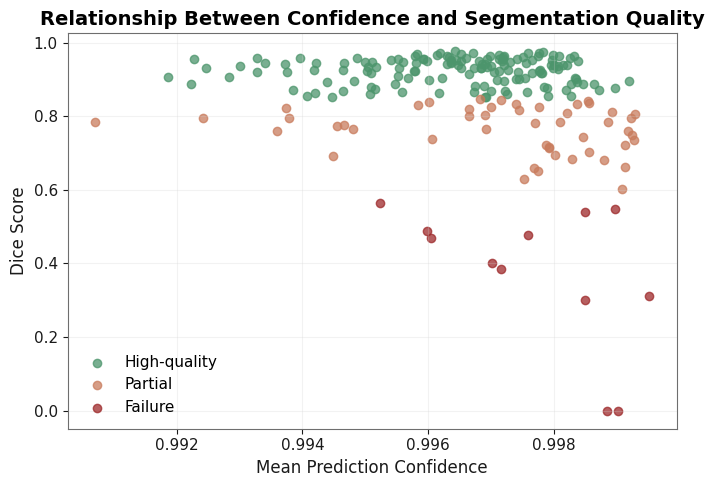

In [ ]:
plt.figure(figsize=(7, 5))

quality_colors = {
    "High-quality": PAPER_COLORS["green"],
    "Partial": PAPER_COLORS["orange"],
    "Failure": PAPER_COLORS["red"],
}

for quality in ["High-quality", "Partial", "Failure"]:
    temp = uncertainty_df[uncertainty_df["case_quality"] == quality]

    plt.scatter(
        temp["mean_confidence"],
        temp["dice"],
        label=quality,
        alpha=0.75,
        color=quality_colors[quality]
    )

plt.xlabel("Mean Prediction Confidence")
plt.ylabel("Dice Score")
plt.title("Relationship Between Confidence and Segmentation Quality")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / "figure_confidence_vs_dice.png", bbox_inches="tight")
plt.show()